In [9]:
from astropy.io import votable
import sys
sys.path.append('../code/')
from dusty_nn_mcmc_utils import run_mcmc, get_lums_r1s, normalize_pars, calculate_scale 
from train_dusty_phoenix_nn import Net, get_wavmask_for_training, Net_spherex, get_dusty_r1_value, Net_phoenix
from train_dusty_r1_nn import Dusty_r1_Net
import torch
from dusty_utils import load_dusty_model
from bbFit.bbFit import BBFit
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from astropy.io import ascii
import pickle
import corner
import pandas as pd


In [7]:
def predict_dusty_model_simple(net, dusty_pars, par_min_vals, par_max_vals):
    # Normalize the parameters first
    norm_pars = normalize_pars(pars=dusty_pars, min_vals=par_min_vals,
                               max_vals=par_max_vals)
    dusty_prediction = net(torch.tensor(norm_pars).float()).detach().numpy()
    return dusty_prediction


In [8]:
g_flux_ujy, g_fluxunc_ujy = 17.804, 2.42 # contemporary g-band flux and uncertainty in uJy
r_flux_ujy, r_fluxunc_ujy = 62.006, 2.383 # contemporary r-band flux and uncertainty in uJy

In [10]:
spec = pd.read_csv('../observational_data/spherex_epoch1.csv')


In [11]:
net_phoenix = Net_phoenix()
net_phoenix.load_state_dict(torch.load('../dusty_models/dusty_ml_interpolator_g00_phoenix_wavs_logtau_predictor.pth'))
net_phoenix.eval()

r1_net_phoenix = Dusty_r1_Net()
r1_net_phoenix.load_state_dict(torch.load('../dusty_models/dusty_ml_interpolator_g00_phoenix_wavs_logtau_r1_predictor.pth'))
r1_net_phoenix.eval()

Dusty_r1_Net(
  (fc1): Linear(in_features=3, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

In [14]:
bb = BBFit(wavs_cm=np.concatenate([[0.4746*1e-4, 0.6366*1e-4], spec['lambda'].values*1e-4]),
           fluxes_jy=np.concatenate([[g_flux_ujy*1e-6, r_flux_ujy*1e-6], spec['flux'].values*1e-6]),
           flux_errs_jy=np.concatenate([[g_fluxunc_ujy*1e-6, r_fluxunc_ujy*1e-6],spec['flux_err'].values*1e-6]),
           dist_mpc=0.77,
           ebv=0.09,
           )

fnus = bb.fnu*1e6
fnuerrs = bb.fnuerr*1e6 #fnus*0.1 
run_wavs = bb.wavs_cm*1e4
run_wavs, fnus, fnuerrs = run_wavs[~np.isnan(fnus)], fnus[~np.isnan(fnus)], fnuerrs[~np.isnan(fnus)]

In [15]:
model1 = ('../dusty_models/sed_2500_1000_0.1_silow_2.0_0.55um.dat')
dusty_model = load_dusty_model(model1)
dusty_model_wavs_phoenix = dusty_model['lam']
wavmask = get_wavmask_for_training(dusty_model_wavs_phoenix)
dusty_model_wavs_phoenix = dusty_model_wavs_phoenix[wavmask]

  0%|          | 0/2000 [00:00<?, ?it/s]/Users/viraj/anaconda3/envs/wntr23bzdiq/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [00:54<00:00, 37.01it/s]


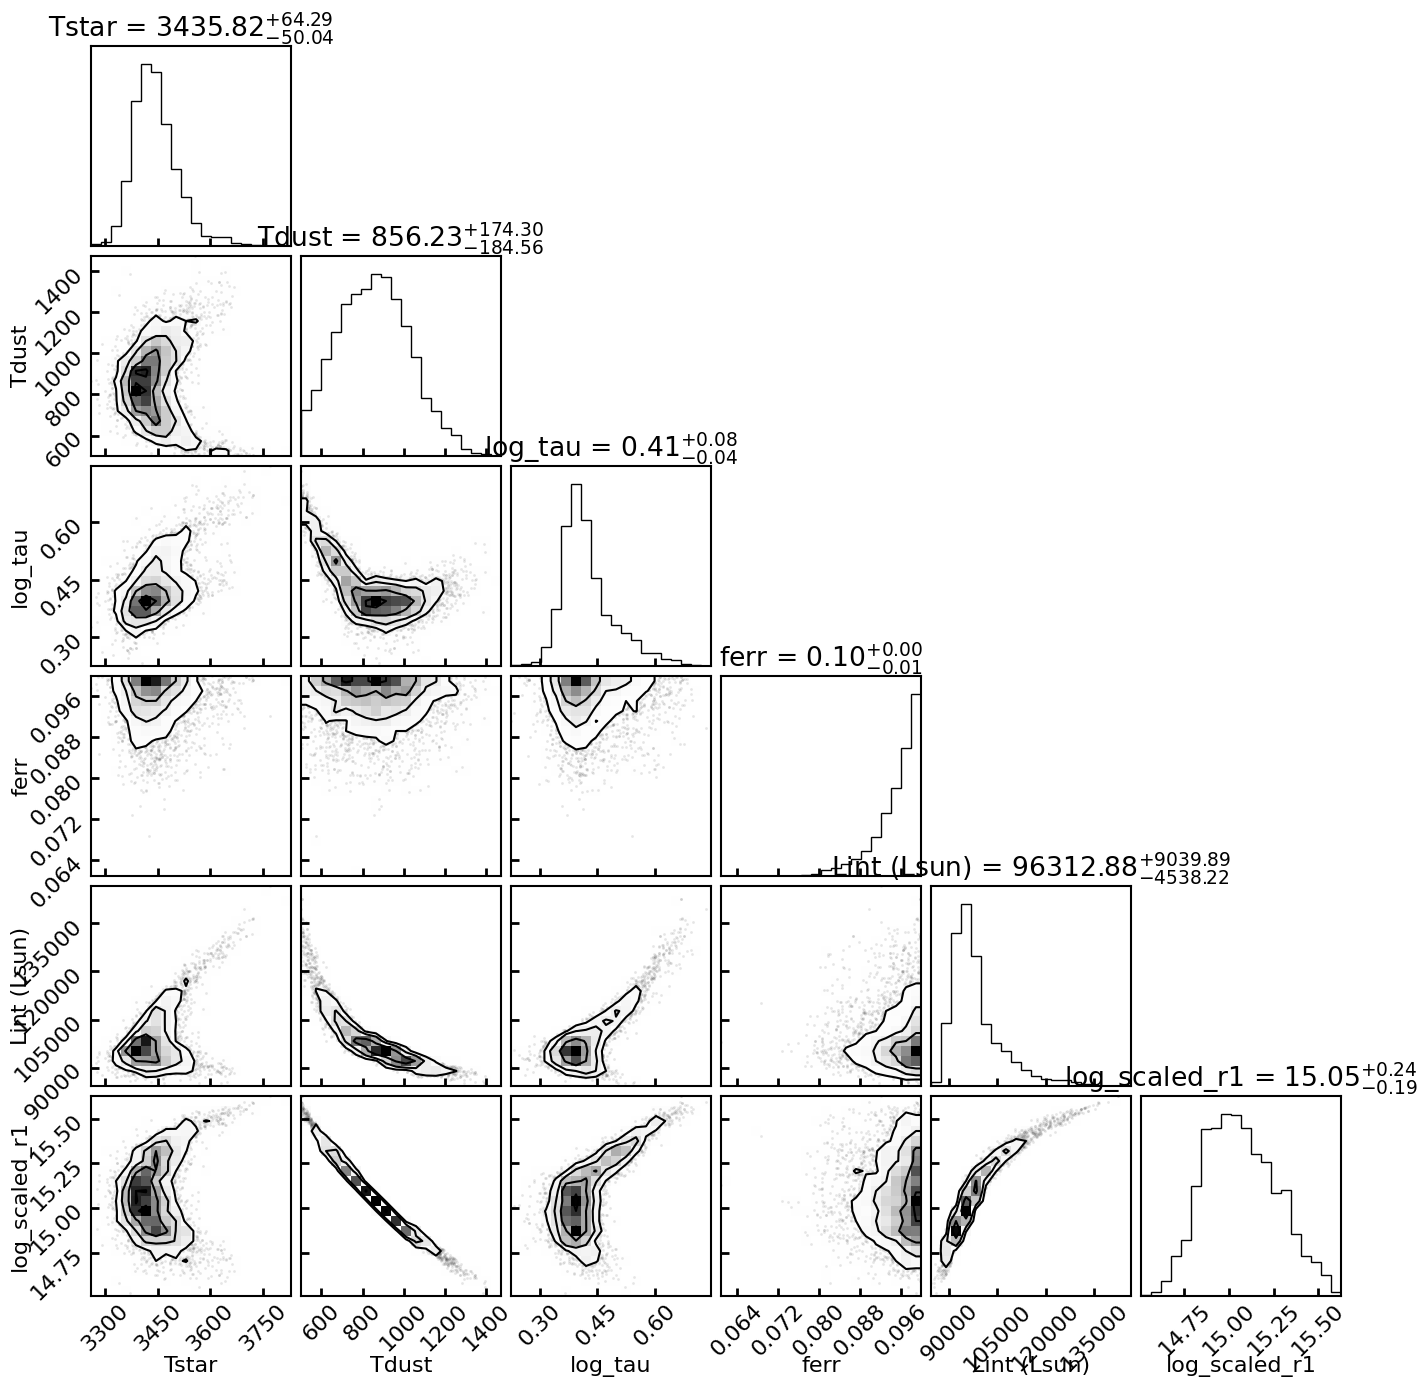

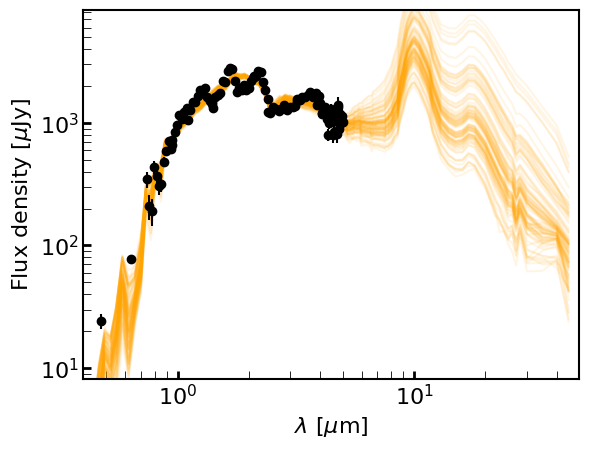

In [16]:
date = 'spherex'
sampler = run_mcmc(run_wavs, fnus, fnuerrs, dusty_model_wavs_phoenix, net_phoenix, r1_net_phoenix, vary_ext=False, 
                   use_error_underestimation=True, 
                   plot_label=f'sed_{date}', nsteps=2000, labels=['Tstar','Tdust','log_tau'], 
                   par_min_vals=np.array([2500, 500, -1]), par_max_vals=np.array([4000, 1500, 1.0]), dist_mpc=bb.dist_mpc,
is_dusty_model_log_tau=True,predict_model=predict_dusty_model_simple)